In [1]:
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 300
import stylia
import pandas as pd
import numpy as np
import os

In [2]:
PATHOGENS = {
    "abaumannii":    "Acinetobacter baumannii",
    "calbicans":     "Candida albicans",
    "campylobacter": "Campylobacter",
    "ecoli":         "Escherichia coli",
    "efaecium":      "Enterococcus faecium",
    "enterobacter":  "Enterobacter",
    "hpylori":       "Helicobacter pylori",
    "kpneumoniae":   "Klebsiella pneumoniae",
    "mtuberculosis": "Mycobacterium tuberculosis",
    "ngonorrhoeae":  "Neisseria gonorrhoeae",
    "paeruginosa":   "Pseudomonas aeruginosa",
    "pfalciparum":   "Plasmodium falciparum",
    "saureus":       "Staphylococcus aureus",
    "smansoni":      "Schistosoma mansoni",
    "spneumoniae":   "Streptococcus pneumoniae",
}

PATH_TO_OUTPUT = os.path.join(".", "..", "output")

# Thresholds mirroring script 15 initial candidate filter
MIN_GROUP_ASSAYS = 2
MIN_GROUP_CPDS   = 100

In [3]:
def parse_assay_ids(assay_keys_series):
    """Return unique assay IDs from a Series of semicolon-separated assay_key strings.

    Each element has the form 'assay_id|activity_type|unit', with multiple
    entries separated by ';'.
    """
    assay_ids = set()
    for keys_str in assay_keys_series.dropna():
        for key in str(keys_str).split(";"):
            parts = key.split("|")
            if parts:
                assay_ids.add(parts[0])
    return assay_ids


def get_base_name(name):
    """Strip the cutoff suffix from a merged model name.

    Examples: 'M_ORG0_20.0' -> 'M_ORG0',  'M_ORG0_r_20.0' -> 'M_ORG0_r'.
    """
    return "_".join(name.split("_")[:-1])


def load_merged_cpds(sel_df, merged_dir):
    """Return a set of unique compound ChEMBL IDs from the selected merged dataset files.

    Decoy compounds (smiles == 'decoy') are excluded.
    """
    cpds = set()
    if len(sel_df) == 0 or not os.path.exists(merged_dir):
        return cpds
    for name in sel_df["name"]:
        fpath = os.path.join(merged_dir, f"{name}.csv.gz")
        if os.path.exists(fpath):
            df = pd.read_csv(fpath, usecols=["compound_chembl_id", "smiles"])
            cpds.update(df[df["smiles"] != "decoy"]["compound_chembl_id"])
    return cpds

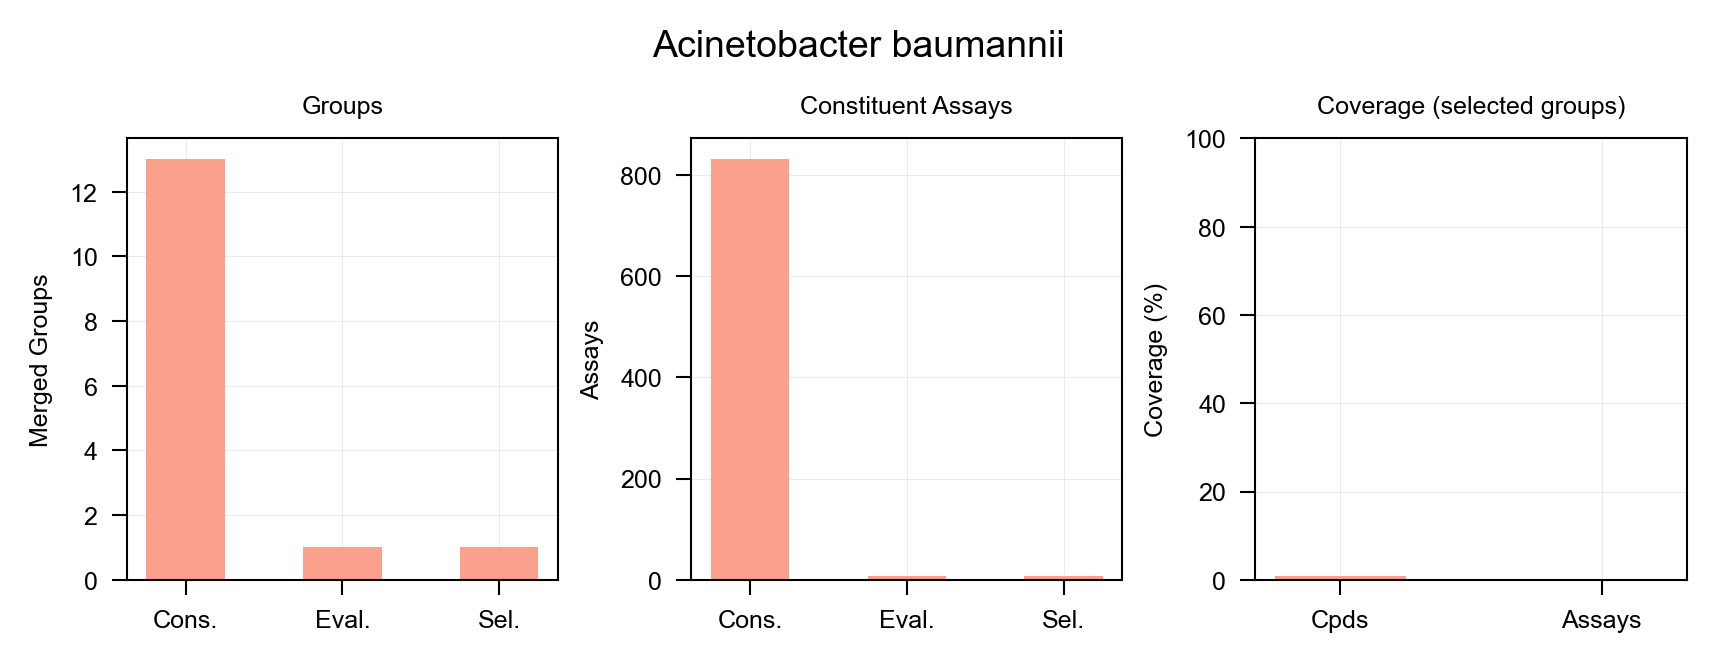

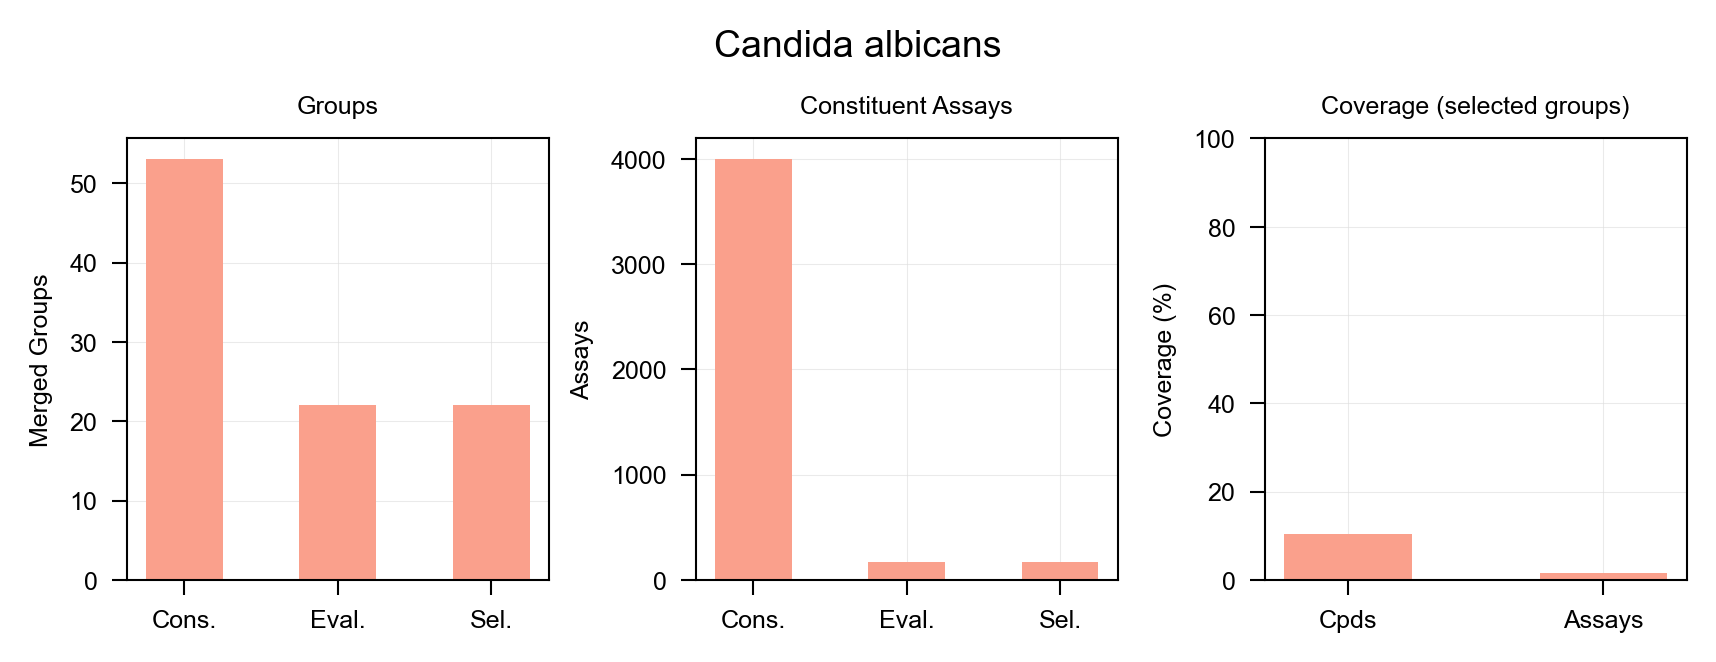

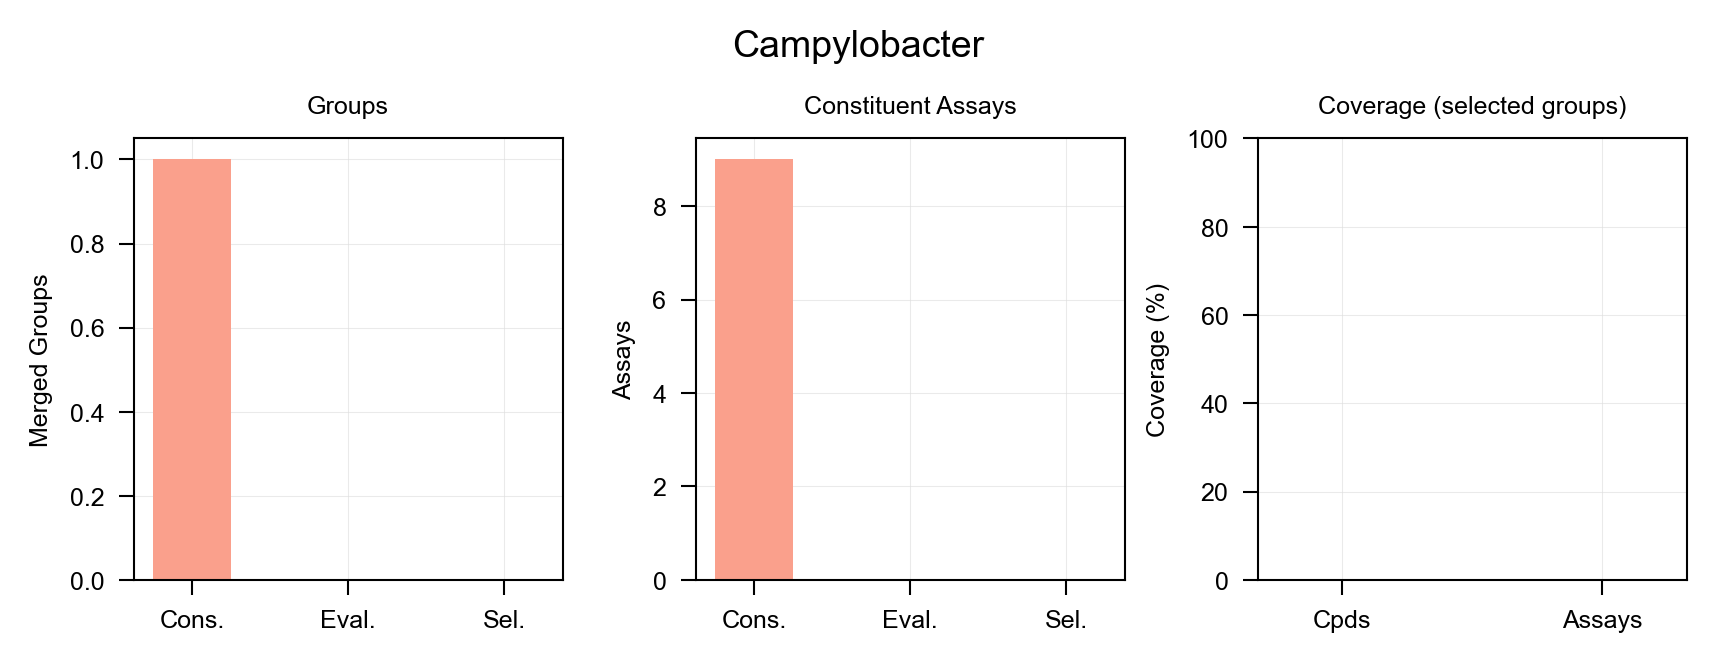

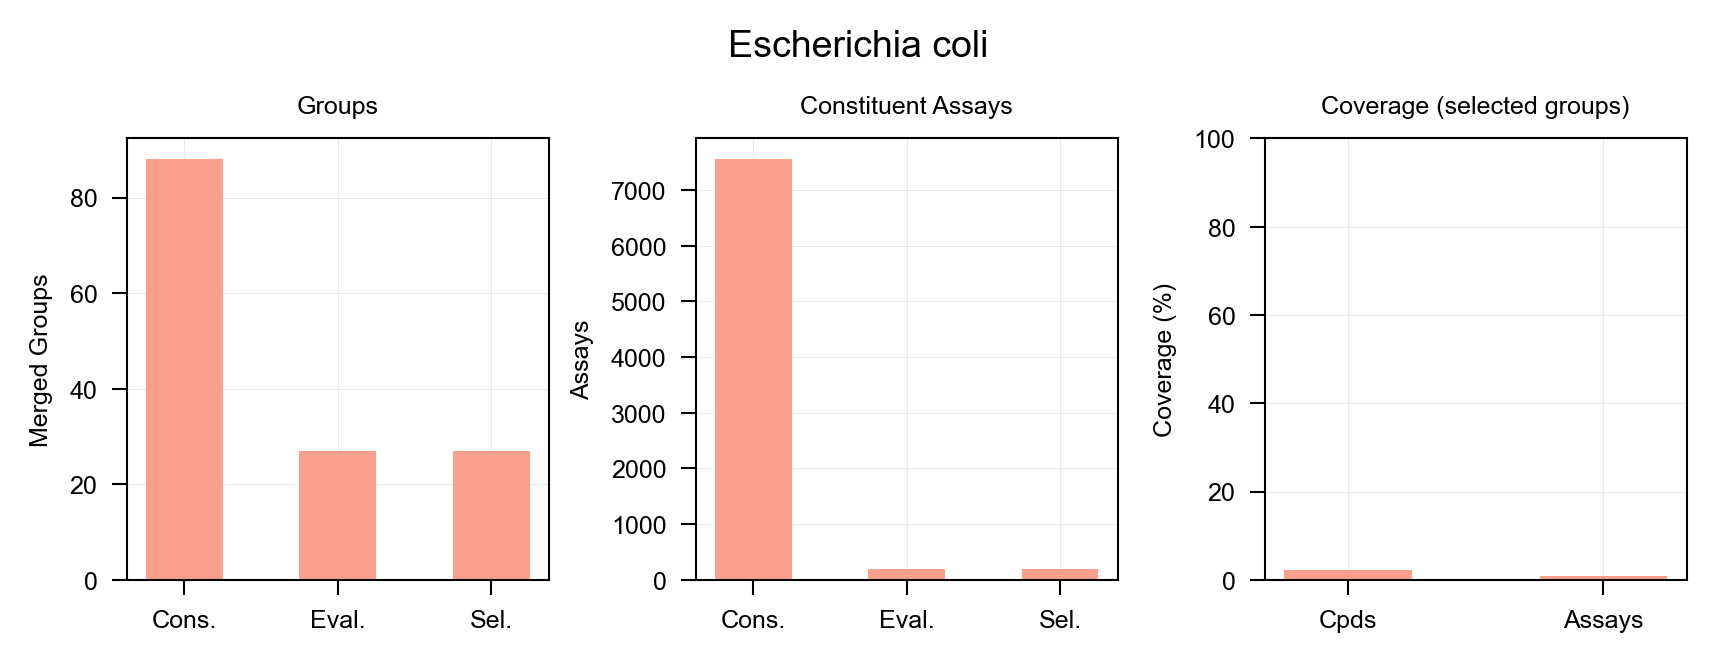

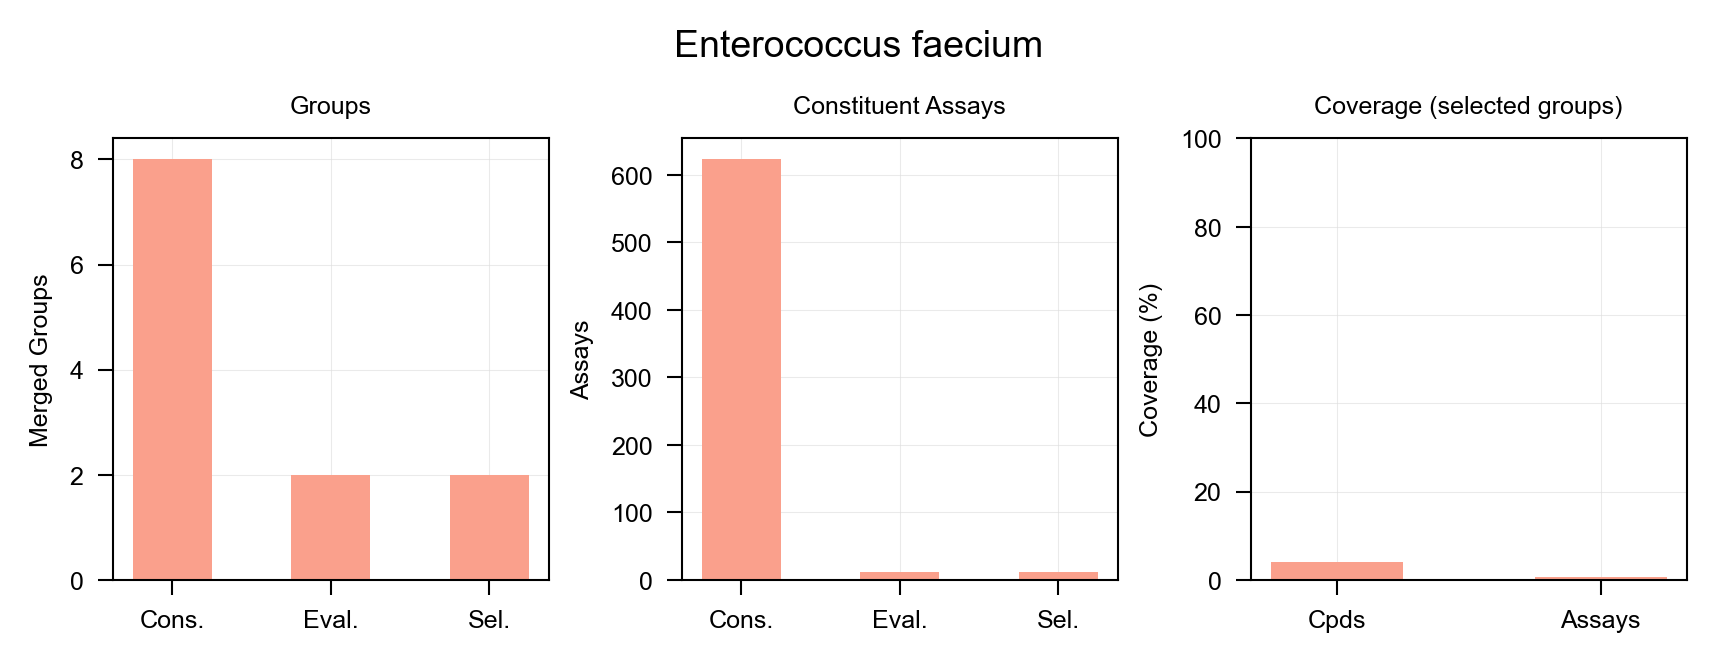

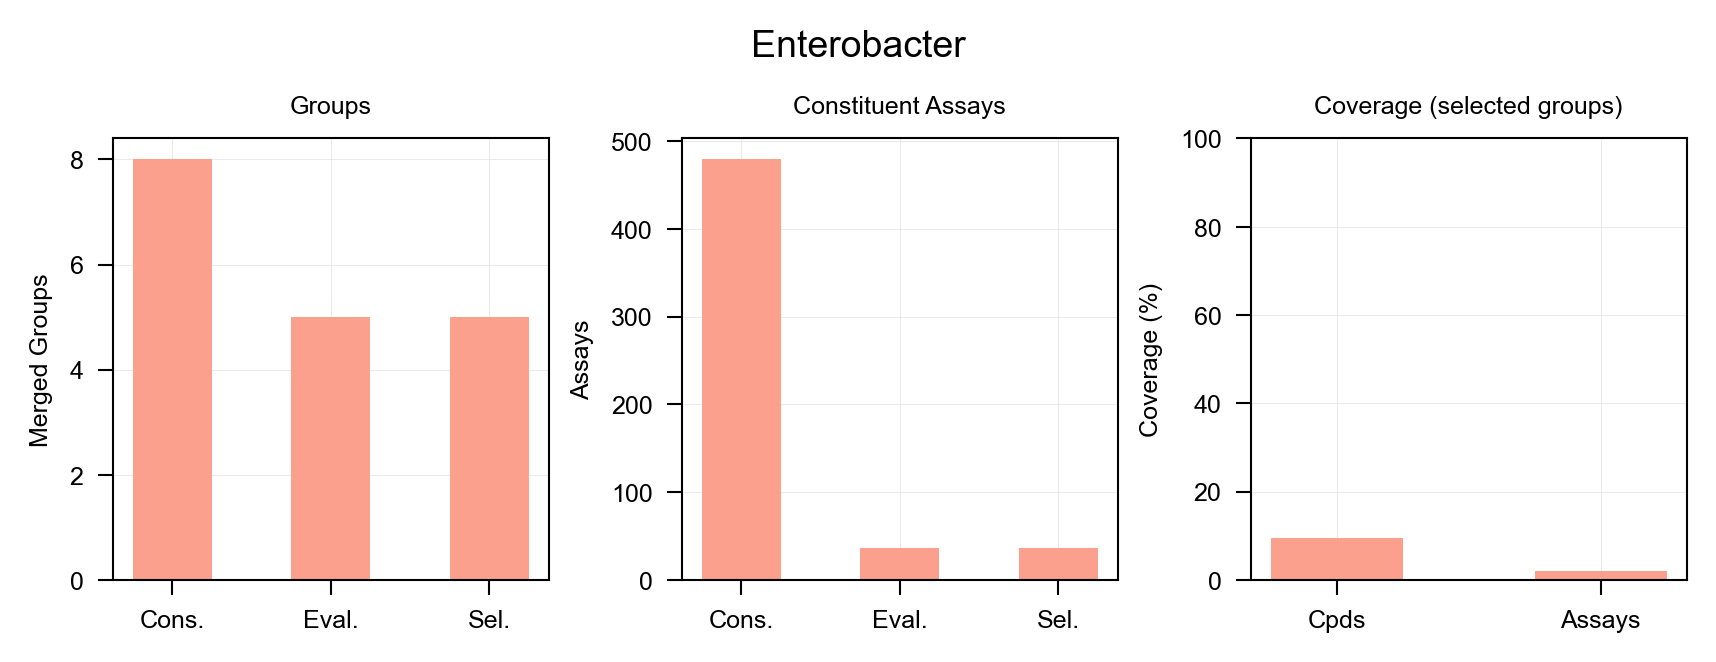

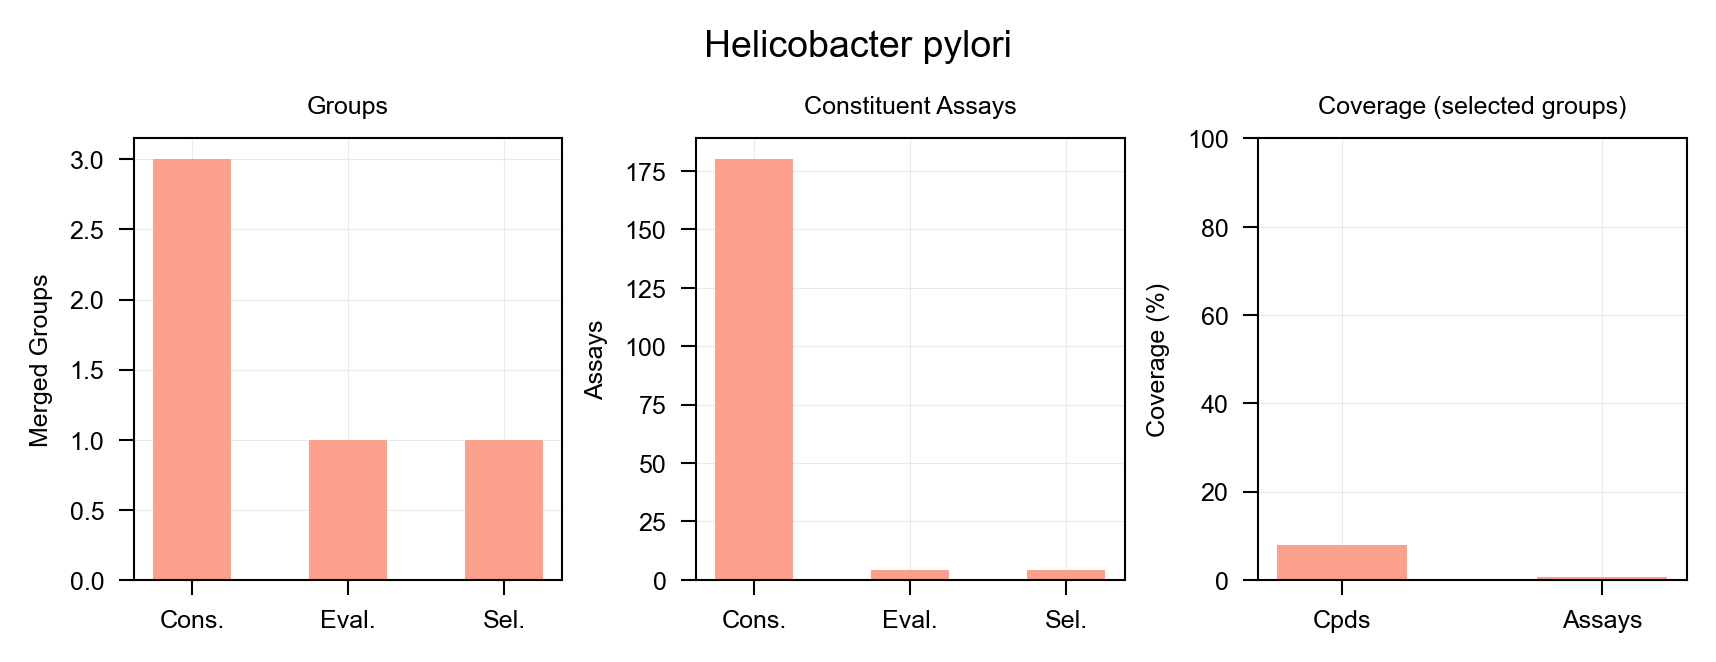

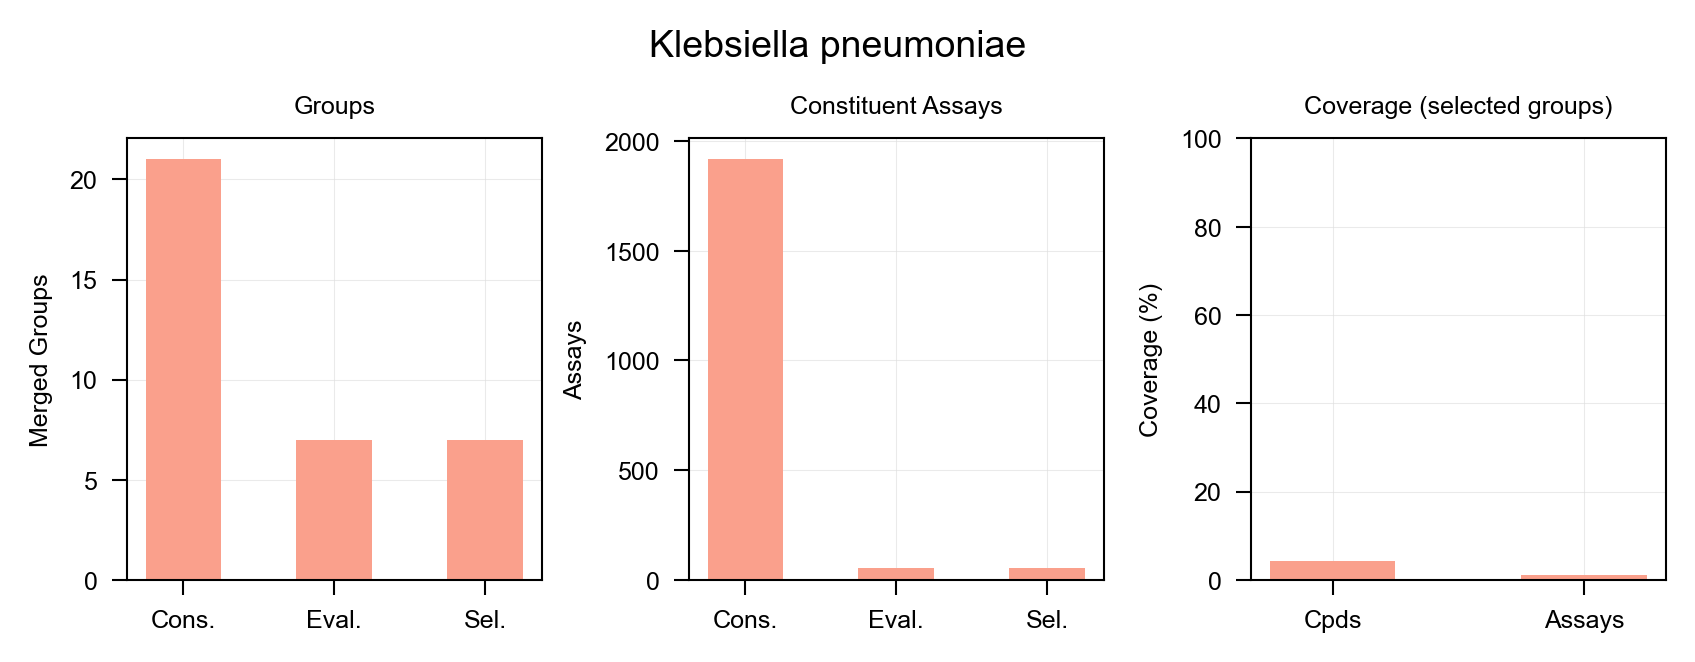

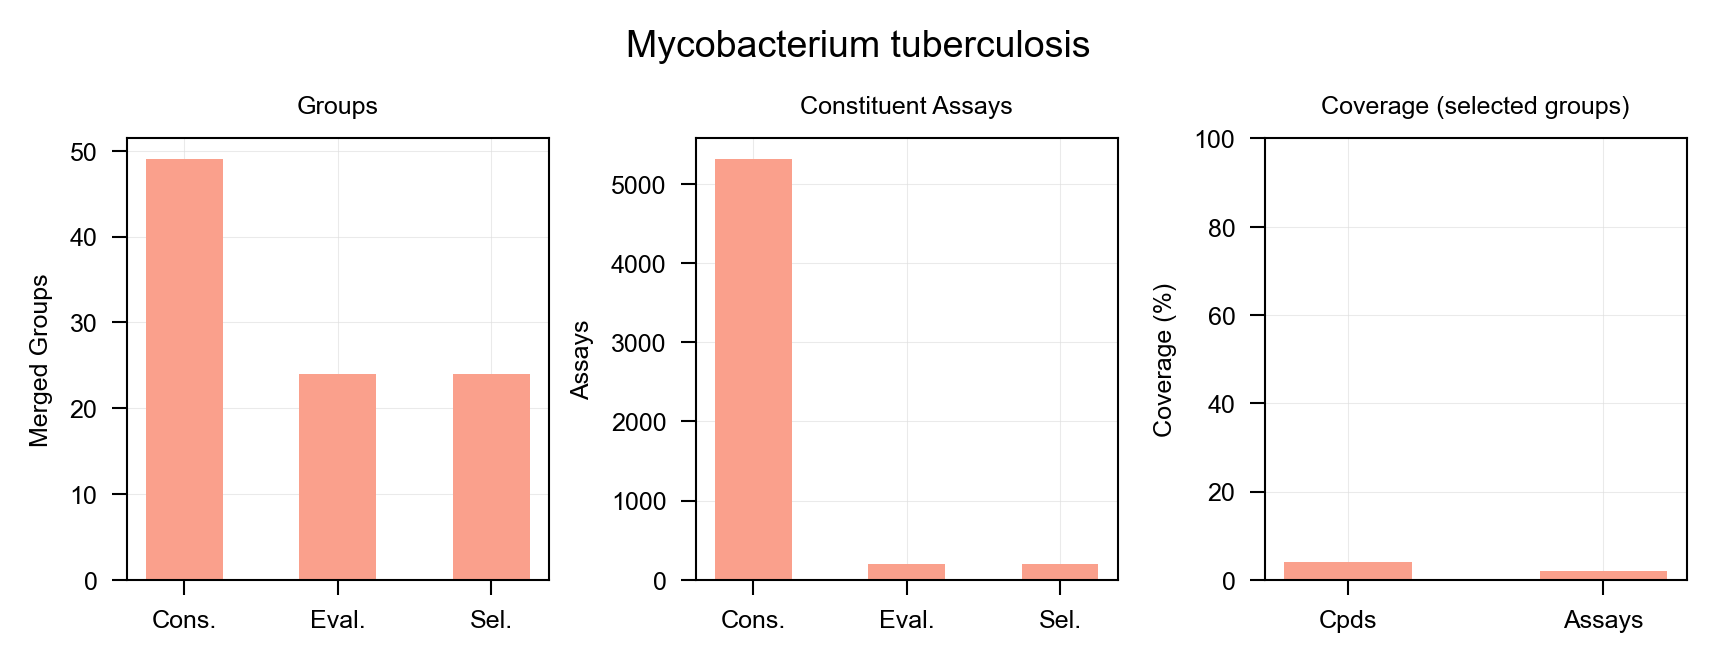

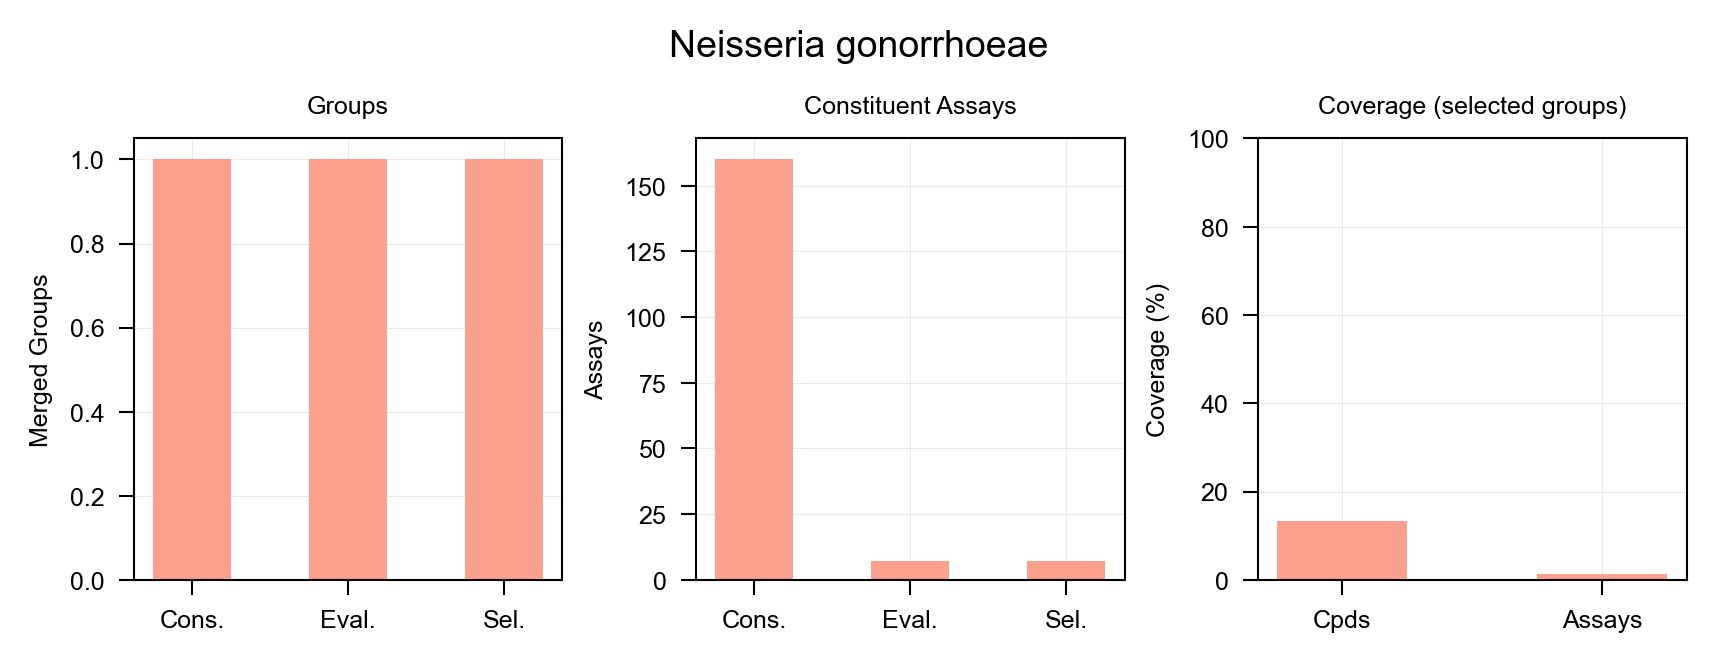

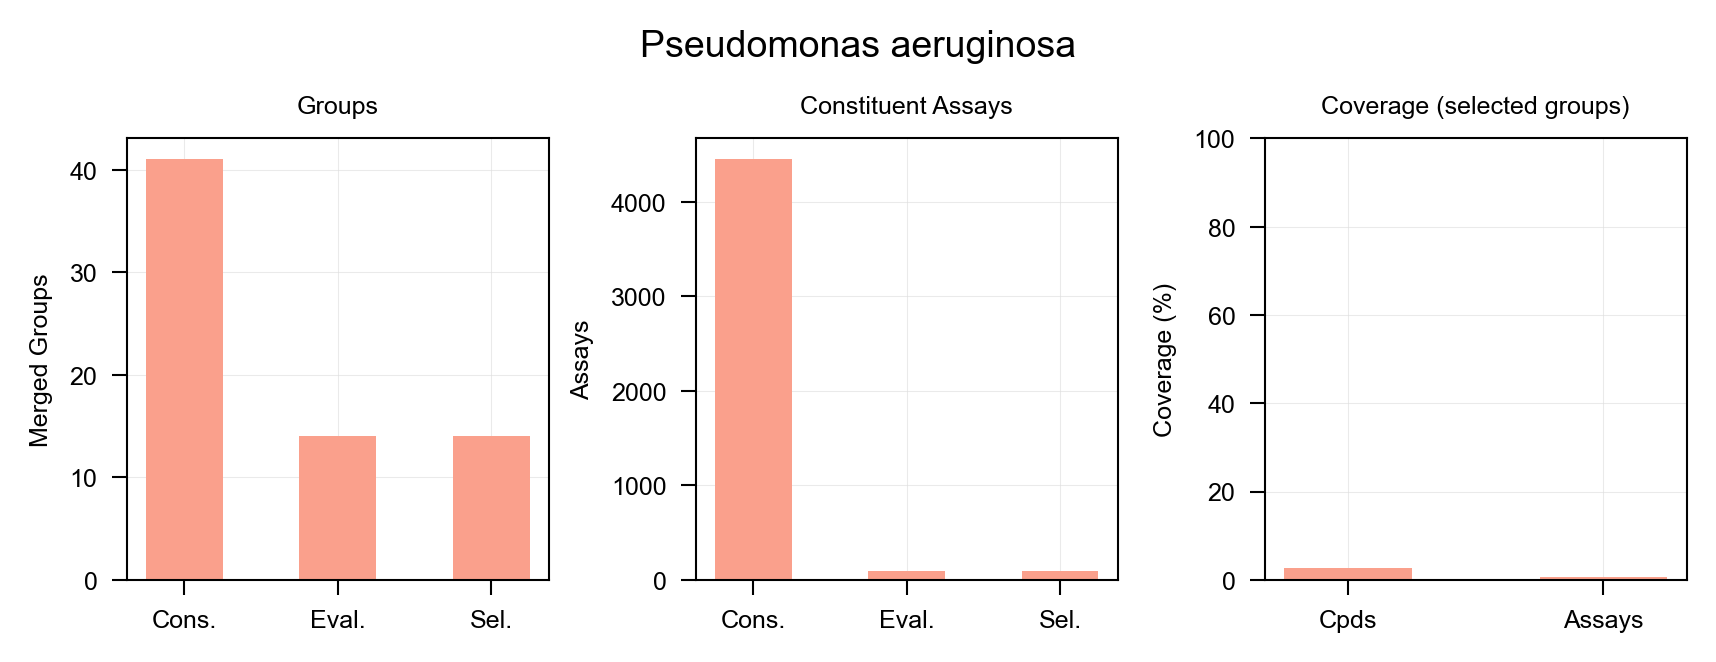

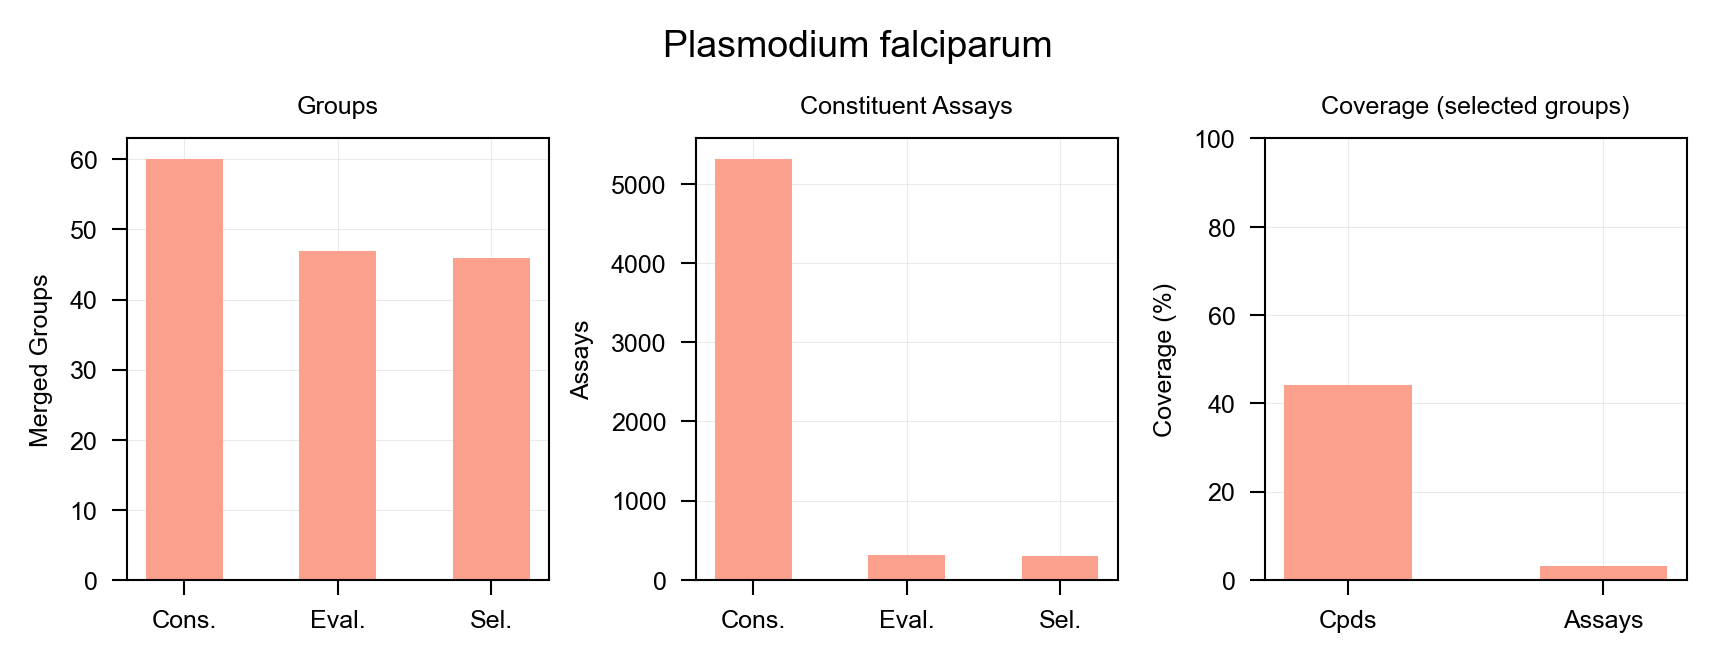

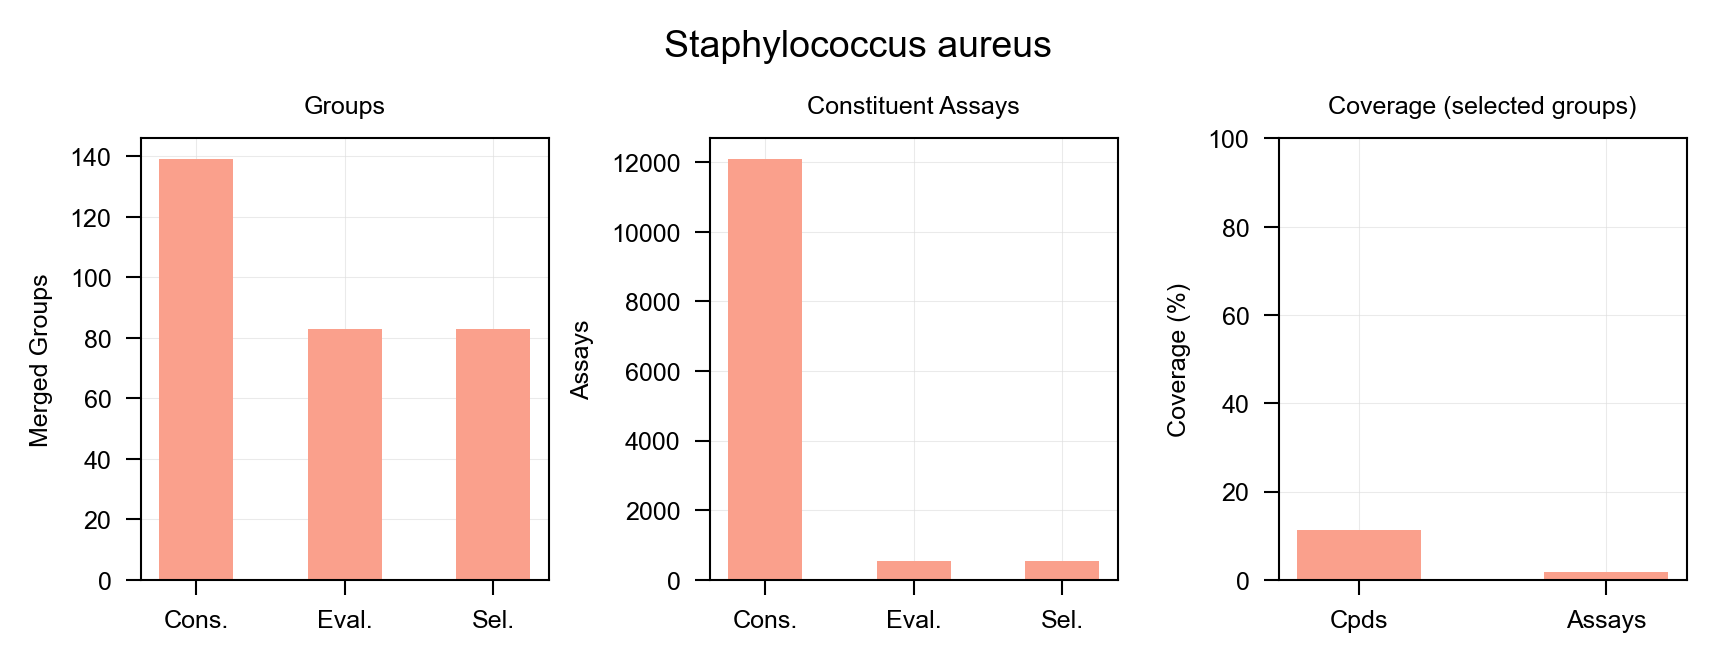

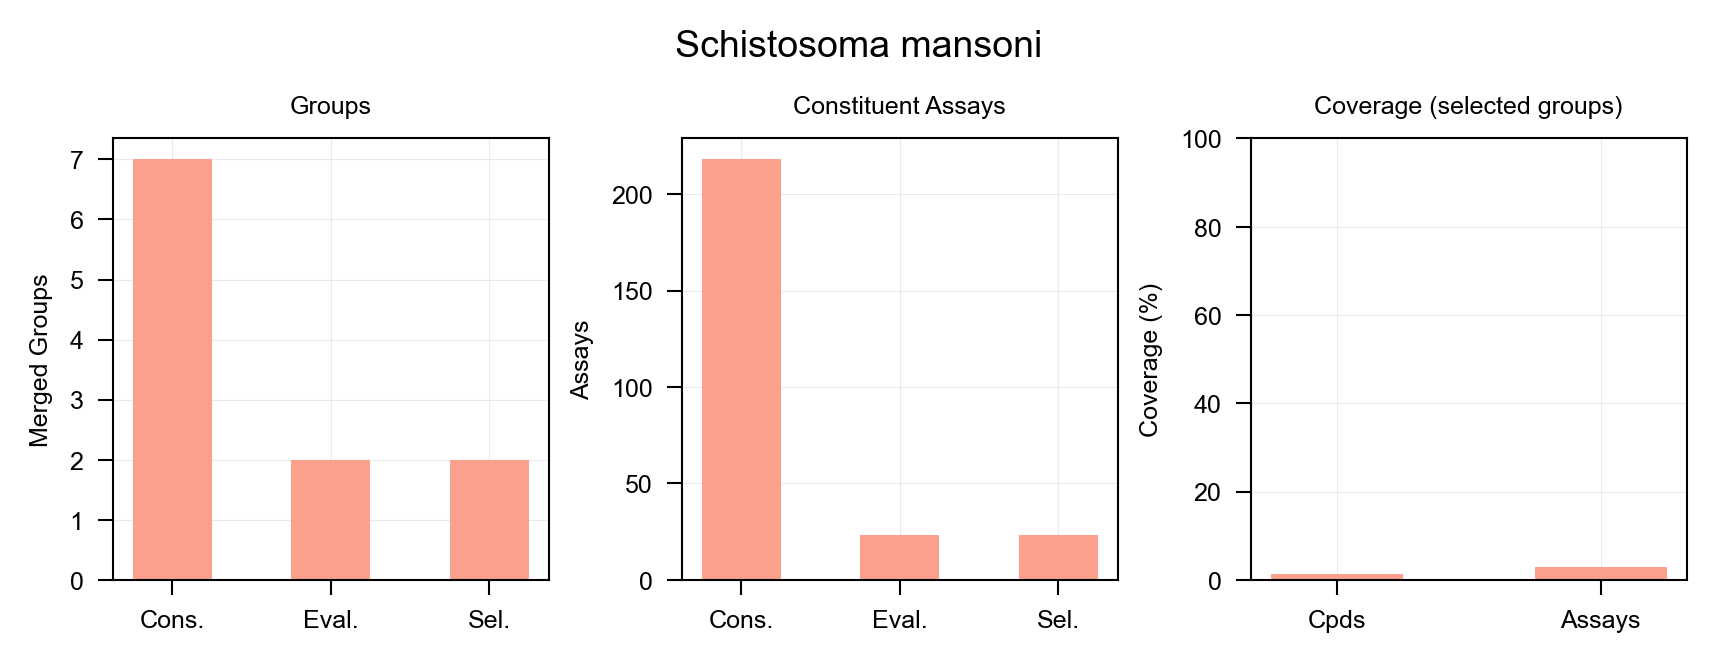

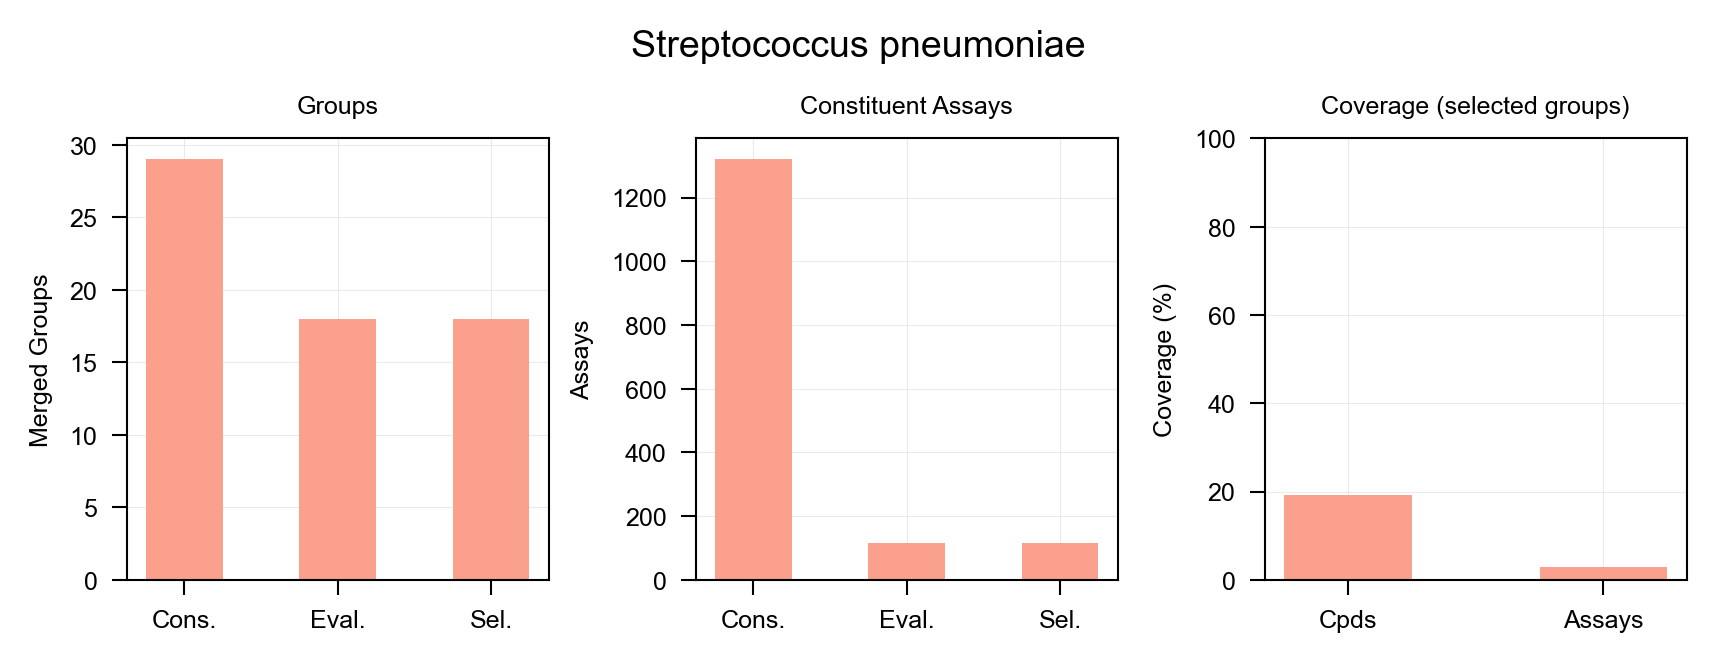

In [4]:
ec     = stylia.ErsiliaColors()
stages = ["Cons.", "Eval.", "Sel."]
x3     = np.arange(3)
x2     = np.arange(2)
w      = 0.5

for PATHOGEN_CODE, PATHOGEN_NAME in PATHOGENS.items():
    base = os.path.join(PATH_TO_OUTPUT, PATHOGEN_CODE)

    path15  = os.path.join(base, "15_merged_LM.csv")
    path15a = os.path.join(base, "15_merging_analysis.csv")
    path16  = os.path.join(base, "16_merged_selected_LM.csv")

    if not os.path.exists(path15) or not os.path.exists(path15a):
        print(f"Skipping {PATHOGEN_NAME} — step 15 not available")
        continue

    df15  = pd.read_csv(path15)
    df15a = pd.read_csv(path15a)
    df16  = pd.read_csv(path16) if os.path.exists(path16) else pd.DataFrame()

    merged_dir   = os.path.join(base, "12_datasets", "M")
    total_cpds   = len(pd.read_csv(os.path.join(base, "07_compound_counts.csv.gz")))
    total_assays = len(pd.read_csv(os.path.join(base, "08_assays_cleaned.csv")))

    # -------------------------------------------------------------------------
    # Stage 1 — Candidates
    # Unique merge groups that passed the initial criteria in script 15:
    # n_assays >= 2 AND n_cpds_union >= 100.
    # MAX group_compounds per group is used to recover the pre-update union size
    # (entries for successfully merged assays can have group_compounds updated
    # to the post-fractional-filter value, while entries still at
    # 'insufficient_fractional_contribution' retain the original value).
    # -------------------------------------------------------------------------
    df15a_groups = (
        df15a.groupby("group_keys", dropna=False)
        .agg(group_size=("group_size", "first"), group_compounds=("group_compounds", "max"))
        .reset_index()
    )

    cand = df15a_groups[
        (df15a_groups["group_size"] >= MIN_GROUP_ASSAYS) &
        (df15a_groups["group_compounds"] >= MIN_GROUP_CPDS)
    ]

    cand_group_keys = set(cand["group_keys"])
    cand_assays = df15a[df15a["group_keys"].isin(cand_group_keys)]["assay_id"].nunique()

    # -------------------------------------------------------------------------
    # Stage 2 — Modeled (step 15)
    # Unique merged model groups (base_name strips the cutoff suffix so that
    # multiple cutoff variants of the same group count as one group).
    # -------------------------------------------------------------------------
    df15["base_name"] = df15["name"].apply(get_base_name)

    n_mod_groups = df15["base_name"].nunique()
    mod_assays   = len(parse_assay_ids(df15["assay_keys"]))

    # -------------------------------------------------------------------------
    # Stage 3 — Selected (step 16)
    # Each row in the step-16 file is one selected merged group (one cutoff
    # per group has already been chosen).
    # -------------------------------------------------------------------------
    n_sel_groups = len(df16)
    sel_assays   = len(parse_assay_ids(df16["assay_keys"])) if len(df16) > 0 else 0

    # -------------------------------------------------------------------------
    # Coverage for selected merged datasets
    # -------------------------------------------------------------------------
    cpds_sel = load_merged_cpds(df16, merged_dir)

    cov = [
        round(100 * len(cpds_sel) / total_cpds, 1)  if total_cpds   > 0 else 0.0,
        round(100 * sel_assays    / total_assays, 1) if total_assays > 0 else 0.0,
    ]

    # -------------------------------------------------------------------------
    # Plot
    # -------------------------------------------------------------------------
    fig, axs = stylia.create_figure(1, 3, width=0.8, height=0.3)

    # --- Groups funnel ---
    ax = axs.next()
    ax.bar(x3, [len(cand), n_mod_groups, n_sel_groups], width=w, color=ec.orange, zorder=2)
    ax.set_xticks(x3)
    ax.set_xticklabels(stages)
    ax.set_xlabel("")
    stylia.label(ax, ylabel="Merged Groups", title="Groups")

    # --- Constituent assays funnel ---
    ax = axs.next()
    ax.bar(x3, [cand_assays, mod_assays, sel_assays], width=w, color=ec.orange, zorder=2)
    ax.set_xticks(x3)
    ax.set_xticklabels(stages)
    ax.set_xlabel("")
    stylia.label(ax, ylabel="Assays", title="Constituent Assays")

    # --- Coverage (selected groups only) ---
    ax = axs.next()
    metrics = ["Cpds", "Assays"]
    ax.bar(x2, cov, width=w, color=ec.orange, zorder=2)
    ax.set_xticks(x2)
    ax.set_xticklabels(metrics)
    ax.set_xlabel("")
    ax.set_ylim(0, 100)
    stylia.label(ax, ylabel="Coverage (%)", title="Coverage (selected groups)")

    plt.suptitle(PATHOGEN_NAME, size=9)
    plt.tight_layout()
    plt.show()